In [2]:
import pandas as pd 
df=pd.read_csv("all_kindle_review.csv")

In [3]:
df.head()

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [4]:
df=df[['reviewText','rating']]

In [5]:
df

,reviewText,rating
0,"Jace Rankin may be short, but he's nothing to ...",3
1,Great short read. I didn't want to put it dow...,5
2,I'll start by saying this is the first of four...,3
3,Aggie is Angela Lansbury who carries pocketboo...,3
4,I did not expect this type of book to be in li...,4
...,...,...
11995,Valentine cupid is a vampire- Jena and Ian ano...,4
11996,I have read all seven books in this series. Ap...,5
11997,This book really just wasn't my cuppa. The si...,3
11998,"tried to use it to charge my kindle, it didn't...",1


In [6]:
df.shape

(12000, 2)

In [7]:
## Missing Values
df.isnull().sum()

reviewText    0
rating        0
dtype: int64

In [8]:
df['rating'].unique()

array([3, 5, 4, 2, 1])

In [9]:
df['rating'].value_counts()

rating
5    3000
4    3000
3    2000
2    2000
1    2000
Name: count, dtype: int64

In [10]:
## Preprocessing and cleaning
## Positive review is 1 and Negetive review is 0
df['rating']=df['rating'].apply(lambda x:0 if x<3 else 1)

In [11]:
df['rating'].unique()

array([1, 0])

In [12]:
df['rating'].value_counts()

rating
1    8000
0    4000
Name: count, dtype: int64

In [13]:
## Lower all the cases
df['reviewText'] = df['reviewText'].str.lower()

In [14]:
df.head()

,reviewText,rating
0,"jace rankin may be short, but he's nothing to ...",1
1,great short read. i didn't want to put it dow...,1
2,i'll start by saying this is the first of four...,1
3,aggie is angela lansbury who carries pocketboo...,1
4,i did not expect this type of book to be in li...,1


In [16]:
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already available
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))  # Load English stopwords

def clean_text(text):
    # 1. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)  
    
    # 2. Remove HTML Tags
    text = re.sub(r'<.*?>', '', text)  
    
    # 3. Remove Special Characters (but keep spaces)
    text = re.sub(r'[^a-z A-Z 0-9\s]', '', text)  
    
    # 4. Remove Stopwords
    text = " ".join([word for word in text.split() if word.lower() not in stop_words])
    
    # 5. Remove Extra Spaces
    text = re.sub(r'\s+', ' ', text).strip()  
    
    return text

# Apply the function to the DataFrame
df['reviewText'] = df['reviewText'].apply(clean_text)


[nltk_data] Downloading package stopwords to /home/ayaan/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [17]:
df.head()

,reviewText,rating
0,jace rankin may short hes nothing mess man hau...,1
1,great short read didnt want put read one sitti...,1
2,ill start saying first four books wasnt expect...,1
3,aggie angela lansbury carries pocketbooks inst...,1
4,expect type book library pleased find price right,1


In [18]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /home/ayaan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [19]:
## Lemmatizer
from nltk.stem import WordNetLemmatizer

In [20]:
lemmatizer=WordNetLemmatizer()

In [21]:
def lemmatize_word(text):
  return " ".join([lemmatizer.lemmatize(word) for word in text.split()])

In [22]:
df['reviewText'] = df['reviewText'].apply(lambda x:lemmatize_word(x))

In [24]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(df['reviewText'],df['rating'],test_size=0.2)

In [25]:
from sklearn.feature_extraction.text import CountVectorizer
bow=CountVectorizer()
X_train_bow = bow.fit_transform(X_train).toarray()
X_test_bow = bow.transform(X_test).toarray()

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

In [27]:
X_train_bow

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [28]:
from sklearn.naive_bayes import GaussianNB
nb_model_bow = GaussianNB().fit(X_train_bow,Y_train)
nb_model_tfidf = GaussianNB().fit(X_train_tfidf,Y_train)

In [29]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [30]:
y_pred_bow = nb_model_bow.predict(X_test_bow)
y_pred_tfidf = nb_model_tfidf.predict(X_test_tfidf)

In [31]:
print(accuracy_score(Y_test,y_pred_bow))

0.5725


In [32]:
print(accuracy_score(Y_test,y_pred_tfidf))

0.5725


In [33]:
print(confusion_matrix(Y_test,y_pred_bow))

[[508 267]
 [759 866]]


In [35]:
from gensim.models import Word2Vec
import numpy as np

# Train Word2Vec model on X_train
word2vec_model = Word2Vec(sentences=X_train, vector_size=100, window=5, min_count=1, workers=4)

# Function to convert sentences to word embeddings (average of word vectors)
def sentence_to_vec(text, model):
    vectors = [model.wv[word] for word in text if word in model.wv]
    return sum(vectors) / len(vectors) if vectors else np.zeros(model.vector_size)

# Convert X_train and X_test into Word2Vec embeddings
X_train_w2v = np.array([sentence_to_vec(sentence, word2vec_model) for sentence in X_train])
X_test_w2v = np.array([sentence_to_vec(sentence, word2vec_model) for sentence in X_test])


In [36]:
nb_model_w2v = GaussianNB().fit(X_train_w2v,Y_train)

In [37]:
y_pred_w2v=nb_model_w2v.predict(X_test_w2v)

In [38]:
print(accuracy_score(Y_test,y_pred_w2v))

0.6408333333333334


## Fix Word2Vec tokenization
The original `Word2Vec(sentences=X_train, ...)` call passed raw review strings instead of token lists, so gensim iterated over *characters* rather than words. Retraining on properly tokenized text below.

In [39]:
tokenized_train = [text.split() for text in X_train]
tokenized_test = [text.split() for text in X_test]

word2vec_model = Word2Vec(sentences=tokenized_train, vector_size=100, window=5, min_count=2, workers=4)

X_train_w2v = np.array([sentence_to_vec(sentence, word2vec_model) for sentence in tokenized_train])
X_test_w2v = np.array([sentence_to_vec(sentence, word2vec_model) for sentence in tokenized_test])

nb_model_w2v = GaussianNB().fit(X_train_w2v, Y_train)
y_pred_w2v = nb_model_w2v.predict(X_test_w2v)
print(accuracy_score(Y_test, y_pred_w2v))

0.7020833333333333


## Logistic Regression
Training Logistic Regression alongside Naive Bayes on all three feature representations (BoW, TF-IDF, Word2Vec) so we can compare models, not just feature sets.

In [40]:
from sklearn.linear_model import LogisticRegression

lr_model_bow = LogisticRegression(max_iter=1000).fit(X_train_bow, Y_train)
lr_model_tfidf = LogisticRegression(max_iter=1000).fit(X_train_tfidf, Y_train)
lr_model_w2v = LogisticRegression(max_iter=1000).fit(X_train_w2v, Y_train)

y_pred_lr_bow = lr_model_bow.predict(X_test_bow)
y_pred_lr_tfidf = lr_model_tfidf.predict(X_test_tfidf)
y_pred_lr_w2v = lr_model_w2v.predict(X_test_w2v)

## Model comparison: accuracy, precision, recall, F1
Evaluating every model/feature combination with `classification_report` (weighted precision/recall/F1) so the comparison isn't accuracy-only.

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = {
    'Naive Bayes + BoW': y_pred_bow,
    'Naive Bayes + TF-IDF': y_pred_tfidf,
    'Naive Bayes + Word2Vec': y_pred_w2v,
    'Logistic Regression + BoW': y_pred_lr_bow,
    'Logistic Regression + TF-IDF': y_pred_lr_tfidf,
    'Logistic Regression + Word2Vec': y_pred_lr_w2v,
}

summary = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': accuracy_score(Y_test, preds),
        'Precision': precision_score(Y_test, preds, average='weighted'),
        'Recall': recall_score(Y_test, preds, average='weighted'),
        'F1-Score': f1_score(Y_test, preds, average='weighted'),
    }
    for name, preds in results.items()
]).sort_values('F1-Score', ascending=False).reset_index(drop=True)

summary

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression + TF-IDF,0.849583,0.847740,0.849583,0.845184
1,Logistic Regression + BoW,0.837917,0.836611,0.837917,0.837148
2,Logistic Regression + Word2Vec,0.771667,0.763546,0.771667,0.762151
3,Naive Bayes + Word2Vec,0.702083,0.750419,0.702083,0.711552
4,Naive Bayes + TF-IDF,0.572500,0.643022,0.572500,0.586096
5,Naive Bayes + BoW,0.572500,0.646996,0.572500,0.585870


In [42]:
print(classification_report(Y_test, y_pred_lr_tfidf, target_names=['negative', 'positive']))

              precision    recall  f1-score   support

    negative       0.83      0.68      0.74       775
    positive       0.86      0.93      0.89      1625

    accuracy                           0.85      2400
   macro avg       0.84      0.80      0.82      2400
weighted avg       0.85      0.85      0.85      2400



## Visualization
Comparing model performance and the underlying class balance the models were trained on.

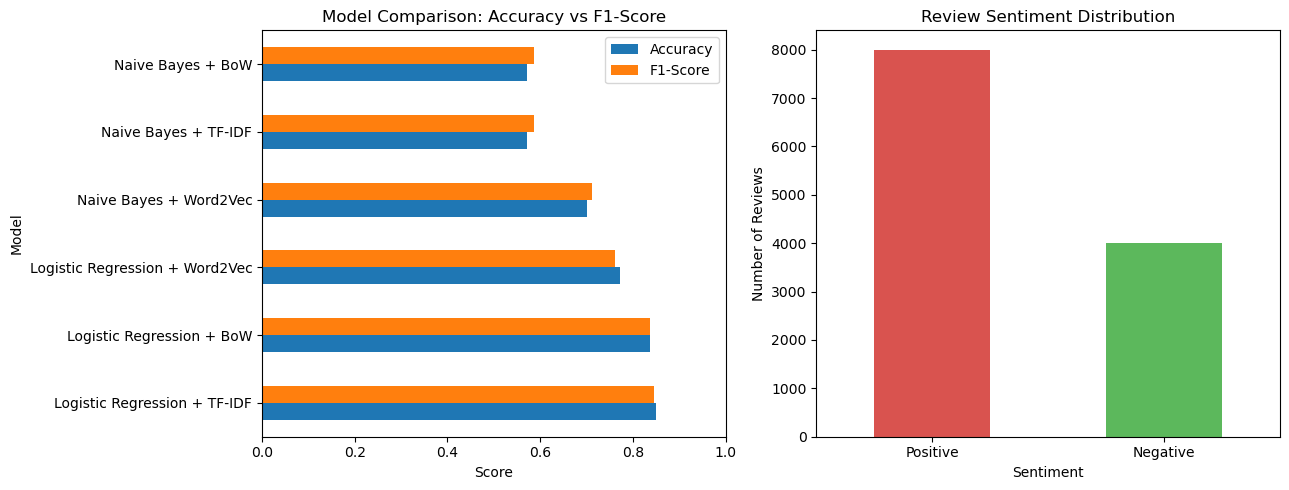

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

summary.set_index('Model')[['Accuracy', 'F1-Score']].plot.barh(ax=axes[0])
axes[0].set_xlabel('Score')
axes[0].set_title('Model Comparison: Accuracy vs F1-Score')
axes[0].set_xlim(0, 1)

df['rating'].value_counts().rename({0: 'Negative', 1: 'Positive'}).plot.bar(ax=axes[1], color=['#d9534f', '#5cb85c'])
axes[1].set_title('Review Sentiment Distribution')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Number of Reviews')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()